# K-Means vs DBSCAN: A Comparative Clustering Tutorial

GitHub:

## 1. Introduction and Setup

Clustering is one of the most common unsupervised machine learning techniques. The idea is to group data points that are similar to each other, without having any labels to work with. It shows up in loads of real world problems like customer segmentation, anomaly detection, and even image processing.

In this tutorial I am going to compare two popular clustering algorithms, K-Means and DBSCAN, and show how they behave differently depending on the shape and quality of the data. I will be using three synthetic datasets to make these differences really clear.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings

from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Data Generation

I created three synthetic datasets using scikit-learn to test different aspects of clustering.

**Dataset A (Well-Separated Blobs)** is made using make_blobs with 3 centres. This is a simple case where both algorithms should do well.

**Dataset B (Non-Convex Moons)** uses make_moons to create two crescent shapes. This is meant to show where K-Means struggles because it assumes round clusters.

**Dataset C (Noisy Blobs)** is similar to Dataset A but I added 50 random noise points on top. This tests whether the algorithm can handle outliers.

In [2]:
# Dataset A: well-separated spherical clusters
X_blobs, y_blobs = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=RANDOM_STATE)

# Dataset B: non-convex crescent shapes
X_moons, y_moons = make_moons(n_samples=300, noise=0.05, random_state=RANDOM_STATE)

# Dataset C: blobs with added random noise
X_noisy_core, y_noisy_core = make_blobs(n_samples=250, centers=3, cluster_std=0.50, random_state=RANDOM_STATE)

noise_points = np.random.uniform(
    low=X_noisy_core.min(axis=0) - 2,
    high=X_noisy_core.max(axis=0) + 2,
    size=(50, 2)
)
X_noisy = np.vstack([X_noisy_core, noise_points])
y_noisy = np.concatenate([y_noisy_core, np.full(50, -1)])

datasets = [
    ('A: Well-Separated Blobs', X_blobs, y_blobs),
    ('B: Non-Convex Moons',     X_moons, y_moons),
    ('C: Noisy Blobs',          X_noisy, y_noisy),
]

for name, X, y in datasets:
    tag = name.split(':')[0].strip().lower()
    df = pd.DataFrame(X, columns=['feature_1', 'feature_2'])
    df['label'] = y
    df.to_csv(f'data/dataset_{tag}.csv', index=False)

for name, X, y in datasets:
    print(f'{name}: {X.shape[0]} samples, {len(set(y) - {-1})} true clusters')

A: Well-Separated Blobs: 300 samples, 3 true clusters
B: Non-Convex Moons: 300 samples, 2 true clusters
C: Noisy Blobs: 300 samples, 3 true clusters


## 3. Visualising Raw Data

Before applying any algorithm, it is always a good idea to visualise the data to see what we are working with.

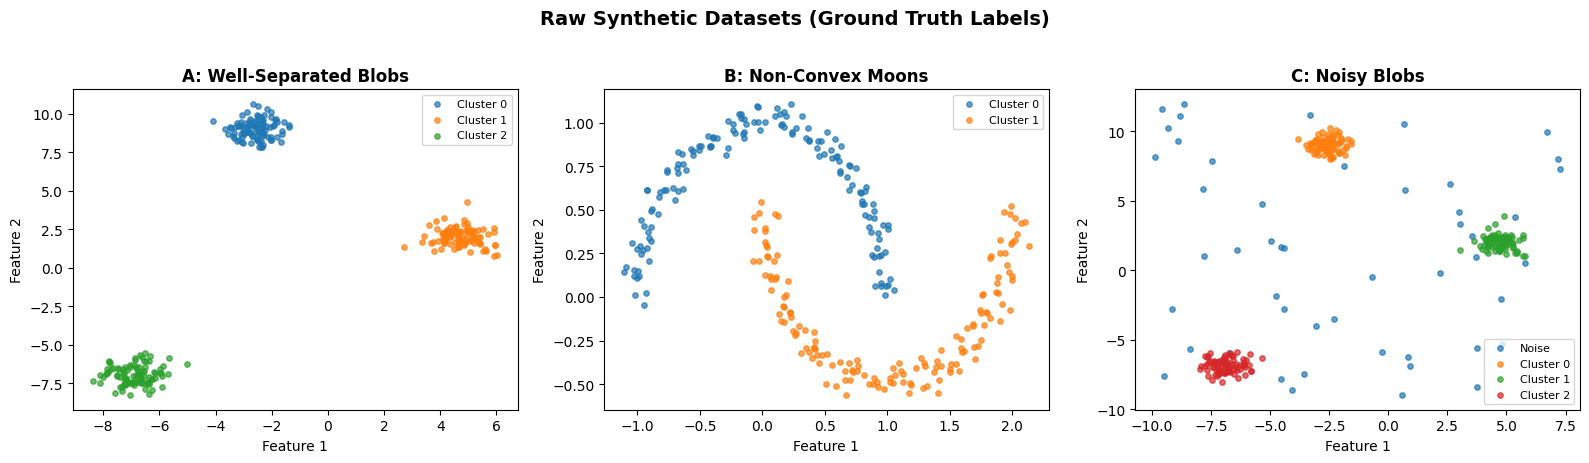

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (name, X, y) in zip(axes, datasets):
    for label in sorted(set(y)):
        mask = y == label
        lbl = 'Noise' if label == -1 else f'Cluster {label}'
        ax.scatter(X[mask, 0], X[mask, 1], s=15, alpha=0.7, label=lbl)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.legend(fontsize=8, loc='best')

fig.suptitle('Raw Synthetic Datasets (Ground Truth Labels)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/raw_datasets.png', dpi=200, bbox_inches='tight')
plt.show()

## 4. K-Means Clustering

K-Means is a centroid based algorithm. It starts by placing k centroids randomly in the data space, assigns every point to its closest centroid, then moves the centroids to the mean of their assigned points. It keeps repeating this until the centroids stop moving.

The big assumption K-Means makes is that clusters are spherical and roughly the same size. This works great for simple data but it breaks down with non-round shapes. It also has no way to deal with noise since it always assigns every point to some cluster.

In [4]:
k_values = [3, 2, 3]

kmeans_results = []

for (name, X, y), k in zip(datasets, k_values):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X)
    centroids = km.cluster_centers_
    kmeans_results.append({'name': name, 'labels': labels, 'centroids': centroids, 'k': k})
    print(f'{name}: K-Means with k={k}, found {len(set(labels))} clusters')

A: Well-Separated Blobs: K-Means with k=3, found 3 clusters
B: Non-Convex Moons: K-Means with k=2, found 2 clusters
C: Noisy Blobs: K-Means with k=3, found 3 clusters


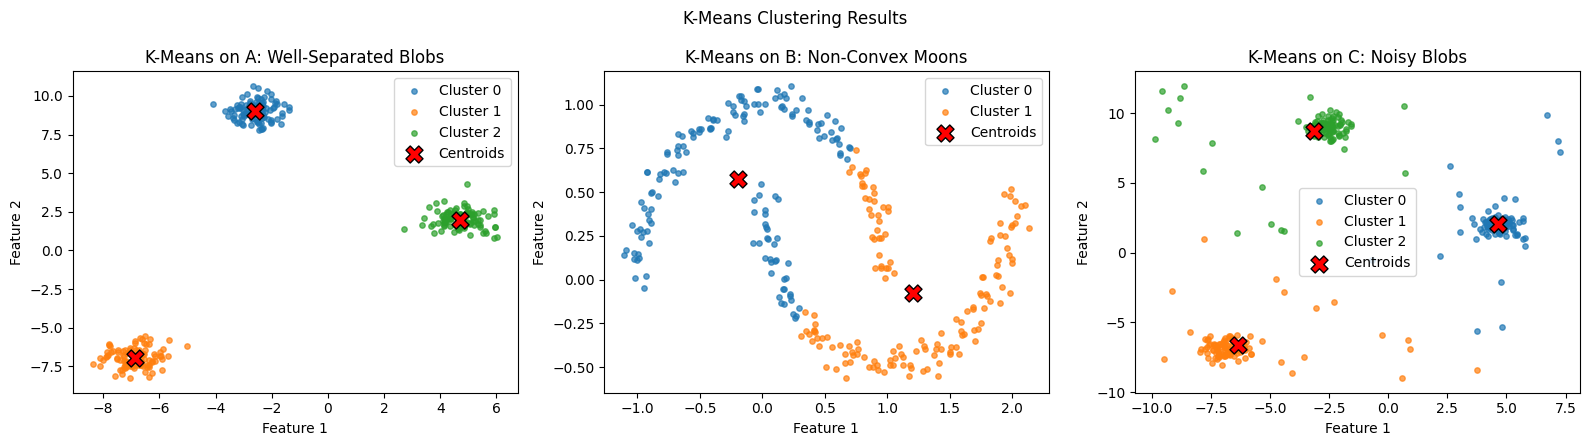

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (name, X, _), res in zip(axes, datasets, kmeans_results):
    labels = res['labels']
    centroids = res['centroids']
    for cl in sorted(set(labels)):
        mask = labels == cl
        ax.scatter(X[mask, 0], X[mask, 1], s=15, alpha=0.7, label=f'Cluster {cl}')
    ax.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=150, edgecolors='black', linewidths=1, label='Centroids', zorder=5)
    ax.set_title(f'K-Means on {name}')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.legend(loc='best')

fig.suptitle('K-Means Clustering Results')
plt.tight_layout()
plt.savefig('images/kmeans_results.png')
plt.show()

## 5. DBSCAN Clustering

DBSCAN stands for Density-Based Spatial Clustering of Applications with Noise. Instead of using centroids, it looks at the density of points. For each point it checks how many neighbours are within a radius called eps. If there are at least min_samples neighbours, that point is considered a core point, and clusters grow outward from core points.

Points that are not close to any core point get labelled as noise (label = -1). This is one of the biggest advantages of DBSCAN, it can naturally detect outliers. It also does not need you to specify the number of clusters beforehand, which is really helpful when you have no idea what the data looks like.

In [6]:
dbscan_params = [
    {'eps': 0.8, 'min_samples': 5},
    {'eps': 0.15, 'min_samples': 5},
    {'eps': 0.7, 'min_samples': 5},
]

dbscan_results = []

for (name, X, y), params in zip(datasets, dbscan_params):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    db = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    labels = db.fit_predict(X_scaled)
    
    n_clusters = len(set(labels) - {-1})
    n_noise = (labels == -1).sum()
    
    dbscan_results.append({
        'name': name, 'labels': labels, 'params': params,
        'n_clusters': n_clusters, 'n_noise': n_noise
    })
    print(f'{name}: DBSCAN (eps={params["eps"]}, min_samples={params["min_samples"]}) found {n_clusters} clusters, {n_noise} noise points')

A: Well-Separated Blobs: DBSCAN (eps=0.8, min_samples=5) found 3 clusters, 0 noise points
B: Non-Convex Moons: DBSCAN (eps=0.15, min_samples=5) found 14 clusters, 19 noise points
C: Noisy Blobs: DBSCAN (eps=0.7, min_samples=5) found 1 clusters, 2 noise points


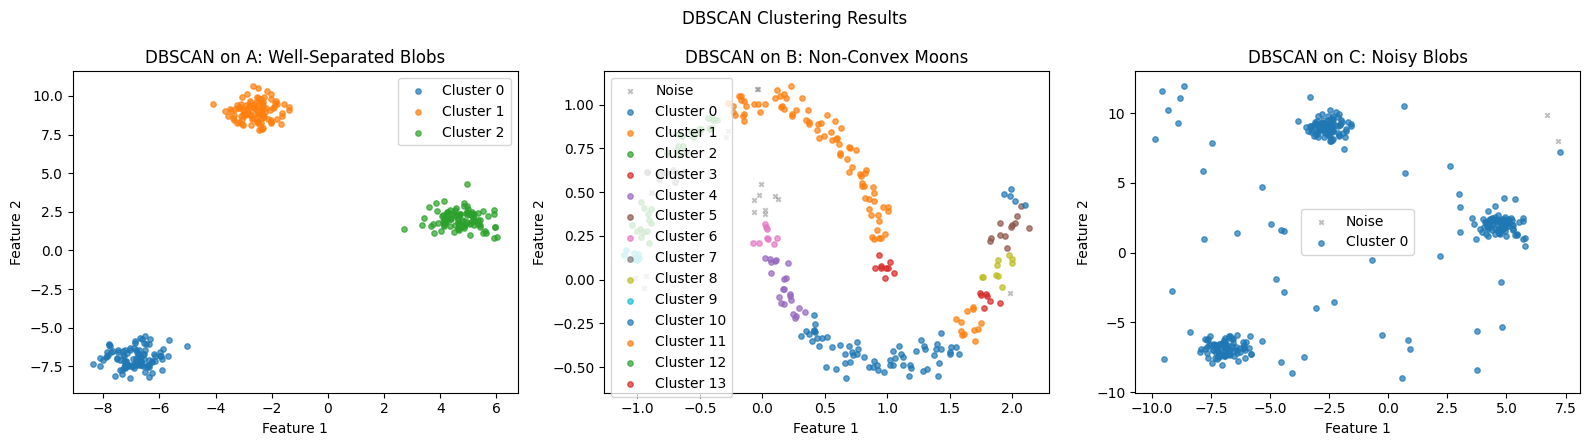

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (name, X, _), res in zip(axes, datasets, dbscan_results):
    labels = res['labels']
    for cl in sorted(set(labels)):
        mask = labels == cl
        if cl == -1:
            ax.scatter(X[mask, 0], X[mask, 1], c='gray', s=10, alpha=0.5, marker='x', label='Noise')
        else:
            ax.scatter(X[mask, 0], X[mask, 1], s=15, alpha=0.7, label=f'Cluster {cl}')
    ax.set_title(f'DBSCAN on {name}')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.legend(loc='best')

fig.suptitle('DBSCAN Clustering Results')
plt.tight_layout()
plt.savefig('images/dbscan_results.png')
plt.show()

## 6. Side-by-Side Comparison

This is the most important figure in the whole tutorial. Each row is one of our datasets, and the columns show the original data, K-Means results, and DBSCAN results side by side. This makes it really easy to spot where each algorithm succeeds or fails.

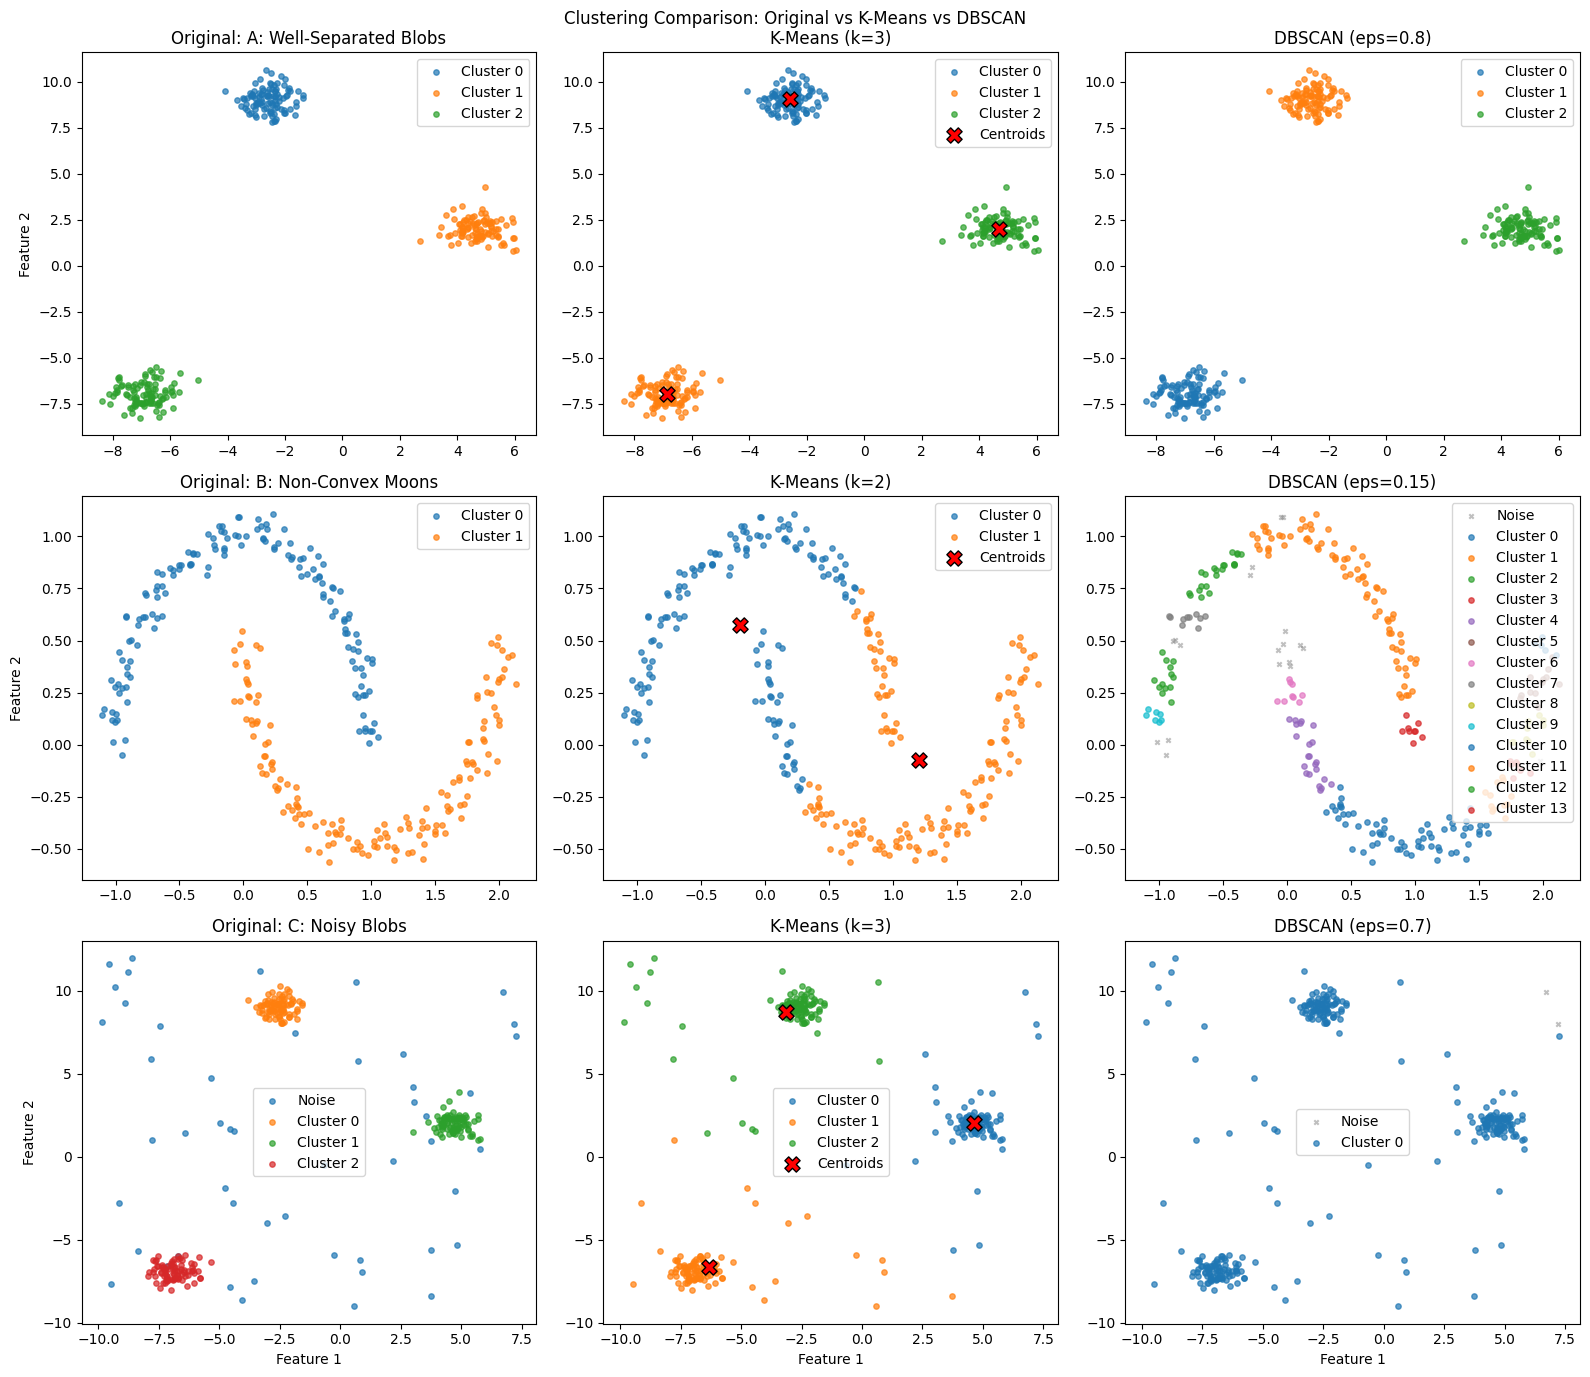

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))

for row, ((name, X, y_true), km_res, db_res) in enumerate(zip(datasets, kmeans_results, dbscan_results)):
    
    ax = axes[row, 0]
    for label in sorted(set(y_true)):
        mask = y_true == label
        lbl = 'Noise' if label == -1 else f'Cluster {label}'
        ax.scatter(X[mask, 0], X[mask, 1], s=15, alpha=0.7, label=lbl)
    ax.set_title(f'Original: {name}')
    ax.set_ylabel('Feature 2')
    ax.legend(loc='best')
    if row == 2:
        ax.set_xlabel('Feature 1')
    
    ax = axes[row, 1]
    km_labels = km_res['labels']
    centroids = km_res['centroids']
    for cl in sorted(set(km_labels)):
        mask = km_labels == cl
        ax.scatter(X[mask, 0], X[mask, 1], s=15, alpha=0.7, label=f'Cluster {cl}')
    ax.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=120, edgecolors='black', linewidths=1, label='Centroids', zorder=5)
    ax.set_title(f'K-Means (k={km_res["k"]})')
    ax.legend(loc='best')
    if row == 2:
        ax.set_xlabel('Feature 1')
    
    ax = axes[row, 2]
    db_labels = db_res['labels']
    for cl in sorted(set(db_labels)):
        mask = db_labels == cl
        if cl == -1:
            ax.scatter(X[mask, 0], X[mask, 1], c='gray', s=10, alpha=0.5, marker='x', label='Noise')
        else:
            ax.scatter(X[mask, 0], X[mask, 1], s=15, alpha=0.7, label=f'Cluster {cl}')
    ax.set_title(f'DBSCAN (eps={db_res["params"]["eps"]})')
    ax.legend(loc='best')
    if row == 2:
        ax.set_xlabel('Feature 1')

fig.suptitle('Clustering Comparison: Original vs K-Means vs DBSCAN')
plt.tight_layout()
plt.savefig('images/comparison_grid.png')
plt.show()

## 7. Quantitative Metrics

Visuals are great but we should also look at some numbers. The silhouette score ranges from -1 to 1 and measures how well points fit their assigned cluster compared to other clusters, so higher is better. I also compare the number of clusters found and how many noise points DBSCAN detected.

In [9]:
metric_rows = []
for (name, X, _), km_res, db_res in zip(datasets, kmeans_results, dbscan_results):
    km_sil = silhouette_score(X, km_res['labels'])
    
    db_labels = db_res['labels']
    non_noise = db_labels != -1
    if len(set(db_labels[non_noise])) > 1:
        db_sil = silhouette_score(X[non_noise], db_labels[non_noise])
    else:
        db_sil = float('nan')
    
    metric_rows.append({
        'Dataset': name,
        'K-Means Clusters': km_res['k'],
        'K-Means Silhouette': round(km_sil, 3),
        'DBSCAN Clusters': db_res['n_clusters'],
        'DBSCAN Noise Points': db_res['n_noise'],
        'DBSCAN Silhouette': round(db_sil, 3) if not np.isnan(db_sil) else 'N/A'
    })

metrics_df = pd.DataFrame(metric_rows)
print('Clustering Metrics Summary')
print(metrics_df.to_string(index=False))

Clustering Metrics Summary
                Dataset  K-Means Clusters  K-Means Silhouette  DBSCAN Clusters  DBSCAN Noise Points DBSCAN Silhouette
A: Well-Separated Blobs                 3               0.908                3                    0             0.908
    B: Non-Convex Moons                 2               0.488               14                   19             0.222
         C: Noisy Blobs                 3               0.800                1                    2               N/A


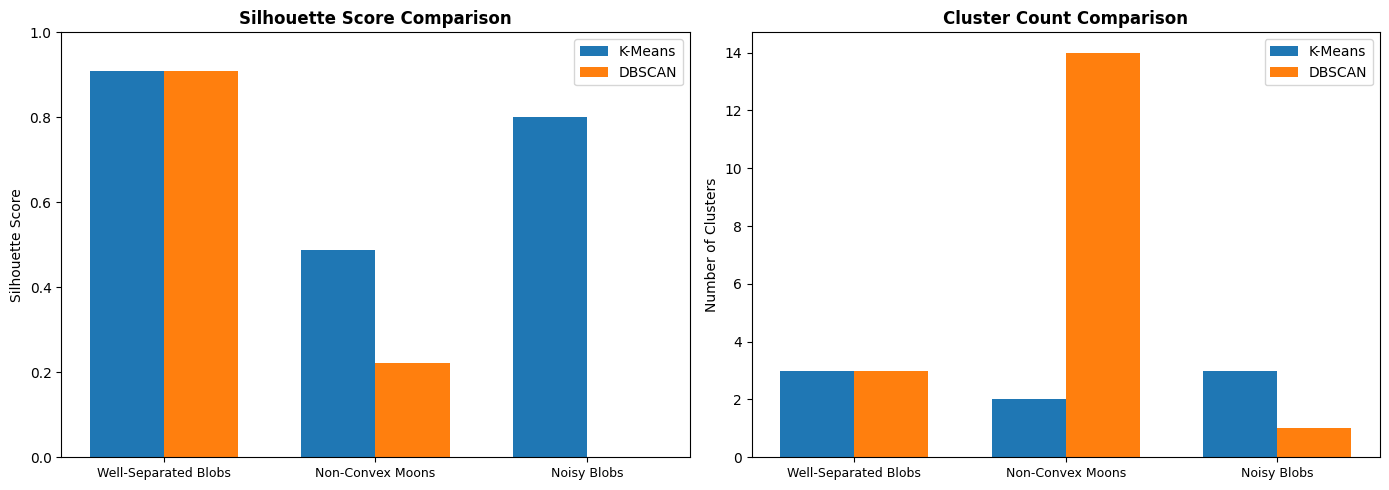

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dataset_names = [name.split(': ')[1] for name, _, _ in datasets]
x = np.arange(len(dataset_names))
width = 0.35

km_silhouettes = [r['K-Means Silhouette'] for r in metric_rows]
db_silhouettes = [r['DBSCAN Silhouette'] if r['DBSCAN Silhouette'] != 'N/A' else 0 for r in metric_rows]

axes[0].bar(x - width/2, km_silhouettes, width, label='K-Means')
axes[0].bar(x + width/2, db_silhouettes, width, label='DBSCAN')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score Comparison', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(dataset_names, fontsize=9)
axes[0].legend()
axes[0].set_ylim(0, 1)

km_clusters = [r['K-Means Clusters'] for r in metric_rows]
db_clusters = [r['DBSCAN Clusters'] for r in metric_rows]

axes[1].bar(x - width/2, km_clusters, width, label='K-Means')
axes[1].bar(x + width/2, db_clusters, width, label='DBSCAN')
axes[1].set_ylabel('Number of Clusters')
axes[1].set_title('Cluster Count Comparison', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(dataset_names, fontsize=9)
axes[1].legend()

plt.tight_layout()
plt.savefig('images/metrics_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

## 8. Discussion and Conclusion

**Dataset A (Well-Separated Blobs):** Both algorithms did well here. The clusters are nicely separated and spherical so K-Means had no trouble finding them. DBSCAN also found all three clusters with very few noise misclassifications. For data like this, K-Means is the simpler and faster option.

**Dataset B (Non-Convex Moons):** This is where things get interesting. K-Means completely fails on this one because it tries to draw straight line boundaries between clusters, which does not work for crescent shapes. DBSCAN on the other hand follows the density of the points and correctly identifies both crescents. This really shows the limitation of K-Means when the data is not round.

**Dataset C (Noisy Blobs):** K-Means assigns every single point to a cluster, even the noise. It has no way to say "this point does not belong anywhere." DBSCAN handles this much better by labelling the scattered noise points as outliers while still finding the three real clusters.

**When to use K-Means:** When you know how many clusters there are and the data is roughly round. It is fast and easy to use.

**When to use DBSCAN:** When you do not know the number of clusters, the data has weird shapes, or there is noise you want to filter out.

The most important lesson from all of this is to always look at your data first. The right algorithm really depends on what the data looks like.
